# CreditPilot — Model Training & Evaluation

## Overview
This notebook focuses on training machine learning models to predict loan default risk using the processed dataset. Multiple models are trained and evaluated to identify the best-performing algorithm.

---

## Objectives

- Train multiple classification models  
- Evaluate model performance using key metrics  
- Compare models and select the best one  
- Save the final model for deployment  

---

## Models Used

- Logistic Regression  
- Random Forest  
- XGBoost  

---

## Evaluation Metrics

- Accuracy  
- Precision  
- Recall  
- F1 Score  
- Confusion Matrix  

---

## Output

- Best trained model saved as:  
  `final_model.pkl`  

---

## Next Step

 Build Financial Stability Index (FSI) & Risk Engine

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import xgboost as xgb
import joblib

In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,age,employment_type,employment_length_years,annual_income,income_stability_score,loan_amount,loan_term_months,interest_rate,loan_type,emi,...,loan_to_income_ratio,num_credit_inquiries,late_payment_count,default_history,repayment_history_score,credit_history_length_years,job_stability_score,spending_to_income_ratio,credit_risk_score,loan_status
0,1.694087,-0.739074,1.541577,-0.450828,1.607075,-0.365883,-0.195427,-1.512826,-0.689882,-0.582169,...,-0.300782,-0.020060,-1.247497,-0.263013,0.814276,1.829270,1.598032,1.168108,-0.920944,0
1,0.799515,0.757027,-0.915354,0.210809,-1.331979,-0.324136,-0.355534,-0.457832,1.023259,-0.352031,...,-0.443067,-0.594841,1.215803,-0.263013,-2.207862,-1.064407,-1.038085,-1.416210,-0.761487,0
2,-0.452886,-0.739074,-0.915354,-0.450828,-0.309700,-0.481535,-0.515642,-0.557760,-0.689882,-0.519678,...,-0.484404,1.704283,3.679103,3.802098,-3.182774,-1.225166,-1.038085,0.898211,-0.763171,1
3,-1.079087,2.253128,-1.406741,-0.450828,-1.715334,-0.202368,-0.515642,0.476072,-1.546452,0.214183,...,-0.041167,-1.169621,-1.247497,-0.263013,1.276855,-1.546686,-1.213826,-0.197016,-0.399412,1
4,0.083857,-0.739074,-1.079150,-0.052938,-0.437485,-0.072868,-0.195427,1.565160,-1.546452,0.009017,...,-0.062873,-1.169621,-1.247497,-0.263013,0.261707,-1.064407,-1.213826,1.093646,0.866214,1


## Split Features & Target

In [3]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

## Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression

In [5]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8915
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       865
           1       0.90      0.91      0.91      1135

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



## Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8845
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       865
           1       0.88      0.92      0.90      1135

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



## XGBoost

In [7]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

/Users/ujjwal/.pyenv/versions/3.11.9/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       865
           1       0.89      0.92      0.90      1135

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



## Confusion Matrix

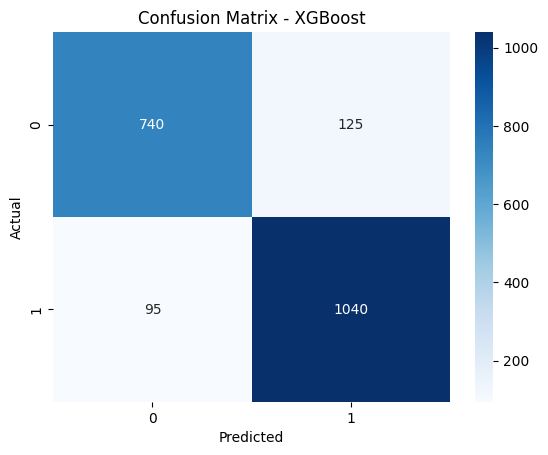

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save Best Model

In [9]:
joblib.dump(xgb_model, "../models/final_model.pkl")

['../models/final_model.pkl']

## Feature Importance

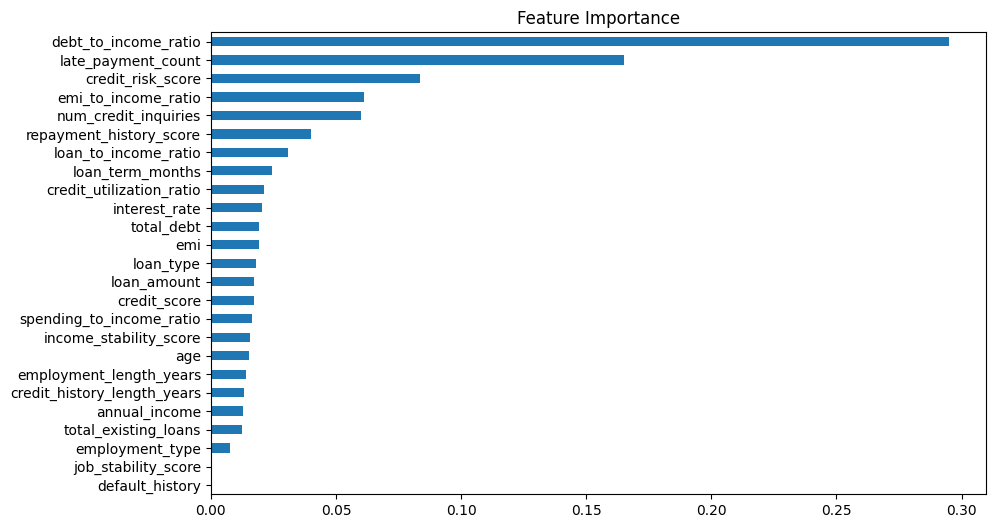

In [10]:
importances = xgb_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Feature Importance")
plt.show()